In [1]:
from transformers import BertTokenizerFast, BertModel
from transformers import RobertaTokenizerFast, RobertaModel
import spacy
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import torch
import os

In [2]:
from data import *
from model import *
from utilsv2 import *

In [3]:
os.environ["TOKENIZERS_PARALLELISM"] = "true"

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Khởi tạo tokenizer và model BERT
tokenizer_bert = BertTokenizerFast.from_pretrained("bert-base-uncased")
bert = BertModel.from_pretrained("bert-base-uncased")

# Thêm token đặc biệt nếu chưa có
special_tokens = {"additional_special_tokens": ["[E1]", "[/E1]", "[E2]", "[/E2]"]}
num_added_toks = tokenizer_bert.add_special_tokens(special_tokens)
bert.resize_token_embeddings(len(tokenizer_bert))  # Resize embedding BERT


# Tokenizer và DataLoader
spacy_nlp = spacy.load('en_core_web_sm')
spacy_nlp.tokenizer = create_custom_tokenizer(spacy_nlp, special_tokens['additional_special_tokens'])

In [5]:
data_source = "/data/ddao/TRE/data/raw_data/TBD/processed/"
data_train_path = data_source + "train.csv"
data_valid_path = data_source + "dev.csv"
data_test_path = data_source + "test.csv"

train_df = pd.read_csv(data_train_path)
valid_df = pd.read_csv(data_valid_path)
test_df = pd.read_csv(data_test_path)

# Mã hóa nhãn
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['label'])
valid_df['label_encoded'] = label_encoder.fit_transform(valid_df['label'])
test_df['label_encoded'] = label_encoder.transform(test_df['label'])  # Ánh xạ giống tập huấn luyện

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"Label Mapping: {label_mapping}")

relations = list(label_mapping.keys())

print("train_df:", train_df.shape)
print("valid_df:", valid_df.shape)
print("test_df:", test_df.shape)

Label Mapping: {'AFTER': 0, 'BEFORE': 1, 'INCLUDES': 2, 'IS_INCLUDED': 3, 'SIMULTANEOUS': 4, 'VAGUE': 5}
train_df: (4032, 12)
valid_df: (629, 12)
test_df: (1427, 12)


In [6]:
print("Create dataloader:")
batch_size = 128
window_size = 128
MAX_LENGTH = 256
shuffle=False
print("batch_size: ", batch_size)
print("window_size: ", window_size)
print("MAX_LENGTH: ", MAX_LENGTH)

Create dataloader:
batch_size:  128
window_size:  128
MAX_LENGTH:  256


In [7]:
train_dataloader_path =  f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/train_dataloader_ws_{window_size}.pt"
validation_dataloader_path = f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/validation_dataloader_ws_{window_size}.pt"
test_dataloader_path = f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/test_dataloader_ws_{window_size}.pt"

In [8]:
train_dataloader = torch.load(train_dataloader_path)
validation_dataloader = torch.load(validation_dataloader_path)
test_dataloader = torch.load(test_dataloader_path)

In [9]:
# ============================================================
# Hyperparameters
# ============================================================
hidden_ffn_dim   = 512
num_heads        = 8
num_layers       = 1
dropout          = 0.3
num_classes      = len(label_encoder.classes_)

num_epochs       = 30
eval_step        = 1
LEARNING_RATE    = 1e-5

top_k            = 10

vague_label_id = label_encoder.transform(["VAGUE"])[0]
print(f"hidden_ffn_dim: {hidden_ffn_dim}")
print(f"num_layers: {num_layers}")
print(f"num_heads: {num_heads}")
print(f"top_k: {top_k}")
print(f"num_classes: {num_classes}")
print(f"vague_label_id: {vague_label_id}")
# ============================================================
# Save path
# ============================================================

save_path = (
    f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/"
    f"FTBERT_TBD_MHA_{num_layers}_FFN_{hidden_ffn_dim}_TOP_{top_k}.pth"
)

# save_path = (
#     f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/"
#     f"FTRoBERTa_TBD_MHA_{num_layers}_FFN_{hidden_ffn_dim}_TOP_{top_k}.pth"
# )
print('Model will save at:', save_path)

hidden_ffn_dim: 512
num_layers: 1
num_heads: 8
top_k: 10
num_classes: 6
vague_label_id: 5
Model will save at: /data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/FTBERT_TBD_MHA_1_FFN_512_TOP_10.pth


In [10]:
print("\nCreate model:")
model = TemporalRelationModelV2(
    bert=bert,
    tokenizer=tokenizer_bert,
    hidden_ffn_dim=hidden_ffn_dim,
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=dropout,
    num_classes=num_classes,
    device=device
).to(device)

print("Device:", device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print("--" * 20)


Create model:
Device: cuda
----------------------------------------


/home/prof/ddao/.local/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


# Analyze result

In [11]:
print("Load pretrained model:")
checkpoint = torch.load(save_path)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']
print(f"Model saved at epoch {epoch}, loss = {loss:.4f}")


Load pretrained model:
Model saved at epoch 29, loss = 0.0146


In [11]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")

Trainable parameters: 131,948,828


In [12]:
num_params_bert = sum(p.numel() for p in bert.parameters() if p.requires_grad)
print(f"Trainable parameters of BERT: {num_params_bert:,}")

Trainable parameters of BERT: 109,485,312


In [13]:
num_params - num_params_bert

22463516

In [14]:
df = pd.read_csv("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/metrics_by_topk.csv", encoding='utf-8-sig')

In [15]:
# Lấy hàng có F1 cao nhất
best_row = df.loc[df['F1'].idxmax()]

best_k = int(best_row['top_k'])
best_f1 = best_row['F1']
best_p = best_row['Precision']
best_r = best_row['Recall']

print(f"✅ Top-K tốt nhất: {best_k}")
print(f"F1 = {best_f1:.4f} | Precision = {best_p:.4f} | Recall = {best_r:.4f}")

✅ Top-K tốt nhất: 8
F1 = 0.8314 | Precision = 0.8314 | Recall = 0.8314


# Get top_k, tokens from training set

In [17]:
from analysis_topk import *

In [14]:
cm, f1, p, r, precisions, recalls, f1s, all_predictions, all_labels, logs = evaluate(test_dataloader,
                                                    model=model,
                                                    top_k=best_k,
                                                    device=device,
                                                    return_preds=True,
                                                    is_TBD=True,
                                                    return_topk_tokens=True,
                                                    return_logs=True,
                                                    vague_label_id=vague_label_id
                                                    )

Evaluating: 100%|██████████| 12/12 [00:07<00:00,  1.70it/s]

Evaluation finished in 7.06s.
Filtered 638/1427 (44.71%) VAGUE samples.
[TBD/MATRES] Accuracy=0.8314, F1=0.8314, P=0.8314, R=0.8314


In [31]:
print(cm)

[[234  17   4  17   2]
 [ 15 349  11   8   1]
 [  7  15  30   2   2]
 [  5  11   0  35   2]
 [  6   6   0   2   8]]


In [18]:
id2label = {v:k for k, v in label_mapping.items()}

In [21]:
# df_expanded = add_is_intra_batch(train_df, batch_size=64)
test_df_no_vague = test_df[test_df["label"] != "VAGUE"]
test_df_no_vague = test_df_no_vague.reset_index(drop=True)
df_expanded = add_is_intra_batch(test_df_no_vague, spacy_nlp, batch_size=64)

In [22]:
d4A = build_analysis_dataset(all_labels,
                             all_predictions,
                             logs,
                             id2label,
                             entity_pairs=df_expanded.values.tolist(),
                             vocab=spacy_nlp.vocab)  # giúp decode id → string)

In [23]:
# Write dictionary to JSON file
with open("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/data4analyze.json", "w") as json_file:
    json.dump(d4A, json_file, indent=4)

In [26]:
df_analysis = create_analysis_dataframe(d4A)

In [27]:
# df_analysis.to_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/train_D4A.json")
df_analysis.to_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/test_D4A.json")


In [22]:
# df_analysis = pd.read_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/train_D4A.json")
df_analysis = pd.read_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/test_D4A.json")

POS distribution per entity_type:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.074303  0.117395  0.033112  0.055767  0.021388  0.102503   
e2           0.090621  0.119613  0.029626  0.053074  0.028200  0.086343   
pair         0.085393  0.118346  0.028200  0.050063  0.027883  0.087294   

pos              INTJ      NOUN       NUM      PART      PRON     PROPN  \
entity_type                                                               
e1           0.000317  0.200729  0.030418  0.029468  0.038973  0.123574   
e2           0.000000  0.206432  0.040558  0.022814  0.036280  0.133555   
pair         0.000634  0.203422  0.039607  0.023764  0.037706  0.139100   

pos             PUNCT     SCONJ       SYM      VERB         X  
entity_type                                                    
e1           0.024715  0.021071  0.001743  0.122307  0.002218  
e2           0.019011 

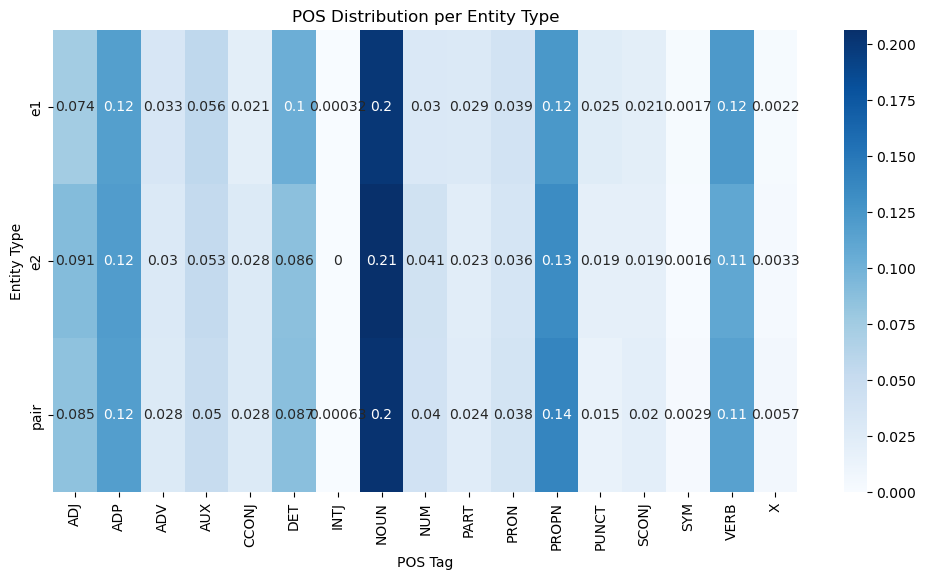

In [23]:
pos_distribution(df_analysis)

Dependency distribution per entity_type:
dep              ROOT       acl     acomp     advcl    advmod     agent  \
entity_type                                                               
e1           0.021229  0.007921  0.004594  0.023131  0.039607  0.001901   
e2           0.018695  0.005862  0.006812  0.018536  0.036280  0.003802   
pair         0.026141  0.006971  0.004436  0.017427  0.032003  0.002218   

dep              amod     appos      attr       aux  ...  parataxis     pcomp  \
entity_type                                          ...                        
e1           0.068758  0.010298  0.002693  0.053866  ...   0.000317  0.007129   
e2           0.086027  0.008555  0.004119  0.048638  ...   0.000951  0.004594   
pair         0.084759  0.005070  0.003961  0.044677  ...   0.000475  0.004278   

dep              pobj      poss      prep       prt     punct  quantmod  \
entity_type                                                               
e1           0.098542  0.00

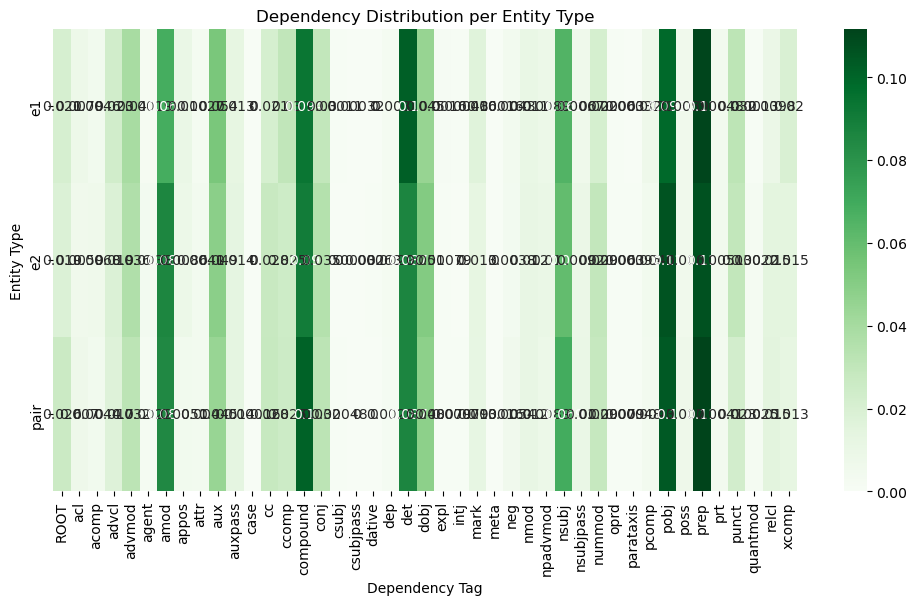

In [24]:
dep_distribution(df_analysis)

Morphology distribution per entity_type:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.215621                              0.021863   
e2           0.201204                              0.029626   
pair         0.203897                              0.026299   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.016318   
e2                                       0.015843   
pair                                     0.016160   

morph        Case=Acc|Gender=Neut|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                           
e1                                                    0.000317        
e2                                                    0.000158        
pair                                                  0.000792        

morph        Case=Acc

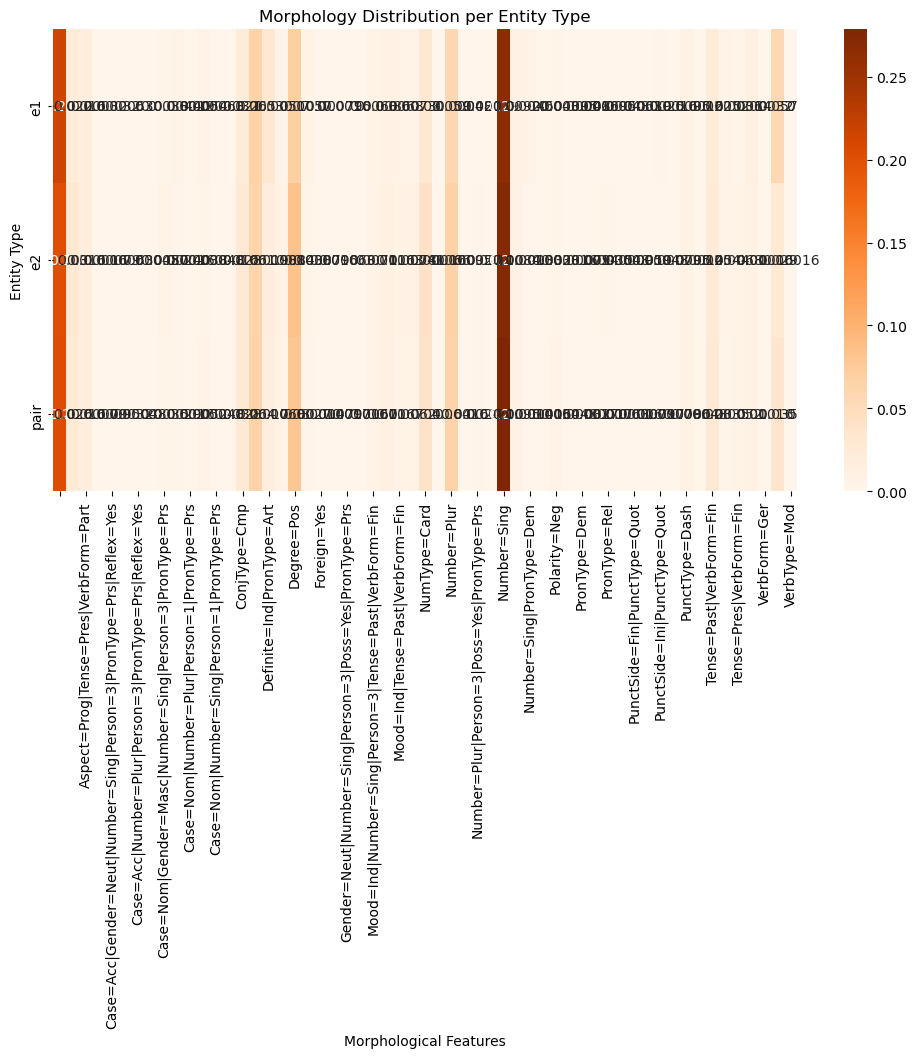

In [25]:
morph_distribution(df_analysis)

POS distribution by entity_type and is_intra:
pos                        ADJ       ADP       ADV       AUX     CCONJ  \
entity_type is_intra                                                     
e1          0         0.072327  0.120283  0.035377  0.072327  0.012579   
            1         0.074802  0.116667  0.032540  0.051587  0.023611   
e2          0         0.085692  0.121069  0.026730  0.077044  0.019654   
            1         0.091865  0.119246  0.030357  0.047024  0.030357   
pair        0         0.082547  0.116352  0.032233  0.067610  0.031447   
            1         0.086111  0.118849  0.027183  0.045635  0.026984   

pos                        DET      INTJ      NOUN       NUM      PART  \
entity_type is_intra                                                     
e1          0         0.096698  0.001572  0.198899  0.025157  0.030660   
            1         0.103968  0.000000  0.201190  0.031746  0.029167   
e2          0         0.071541  0.000000  0.213836  0.048742  0.0

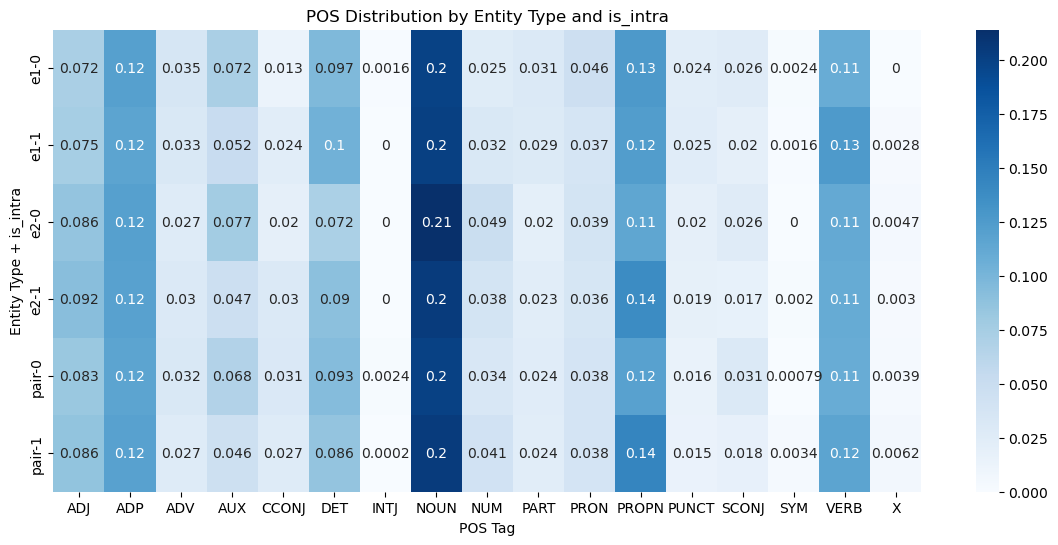

Dependency distribution by entity_type and is_intra:
dep                       ROOT       acl     acomp     advcl    advmod  \
entity_type is_intra                                                     
e1          0         0.022013  0.007075  0.007862  0.031447  0.044025   
            1         0.021032  0.008135  0.003770  0.021032  0.038492   
e2          0         0.023585  0.004717  0.011792  0.028302  0.033805   
            1         0.017460  0.006151  0.005556  0.016071  0.036905   
pair        0         0.030660  0.005503  0.008648  0.011006  0.040094   
            1         0.025000  0.007341  0.003373  0.019048  0.029960   

dep                      agent      amod     appos      attr       aux  ...  \
entity_type is_intra                                                    ...   
e1          0         0.004717  0.062107  0.011006  0.006289  0.052673  ...   
            1         0.001190  0.070437  0.010119  0.001786  0.054167  ...   
e2          0         0.005503  0.0746

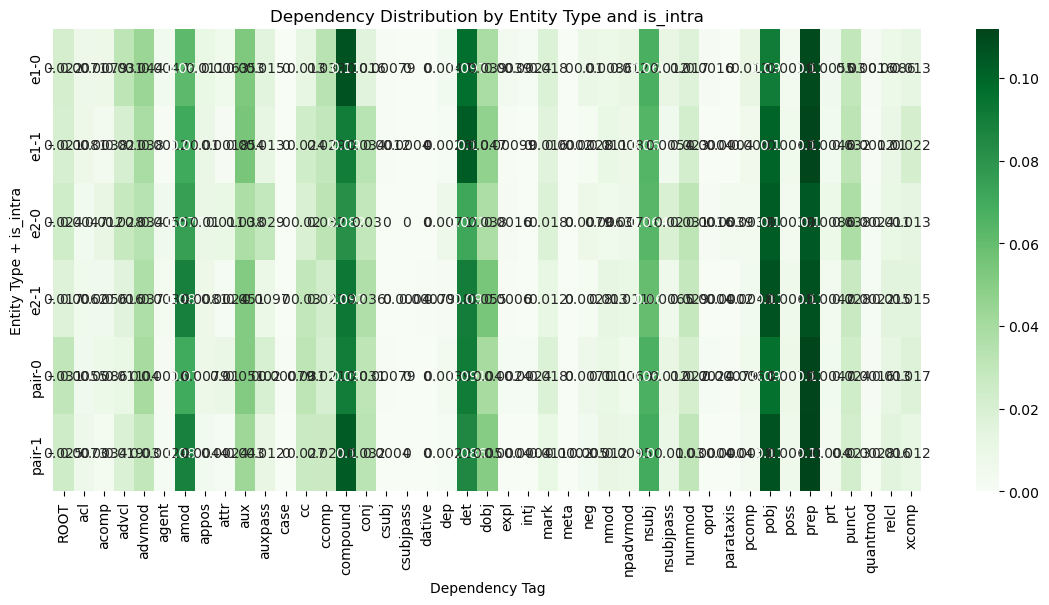

Morphology distribution by entity_type and is_intra:
morph                           Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type is_intra                                                   
e1          0         0.225629                              0.028302   
            1         0.213095                              0.020238   
e2          0         0.198113                              0.035377   
            1         0.201984                              0.028175   
pair        0         0.213050                              0.025157   
            1         0.201587                              0.026587   

morph                 Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type is_intra                                         
e1          0                                     0.021226   
            1                                     0.015079   
e2          0                                     0.018082   
            1                                     0.015278  

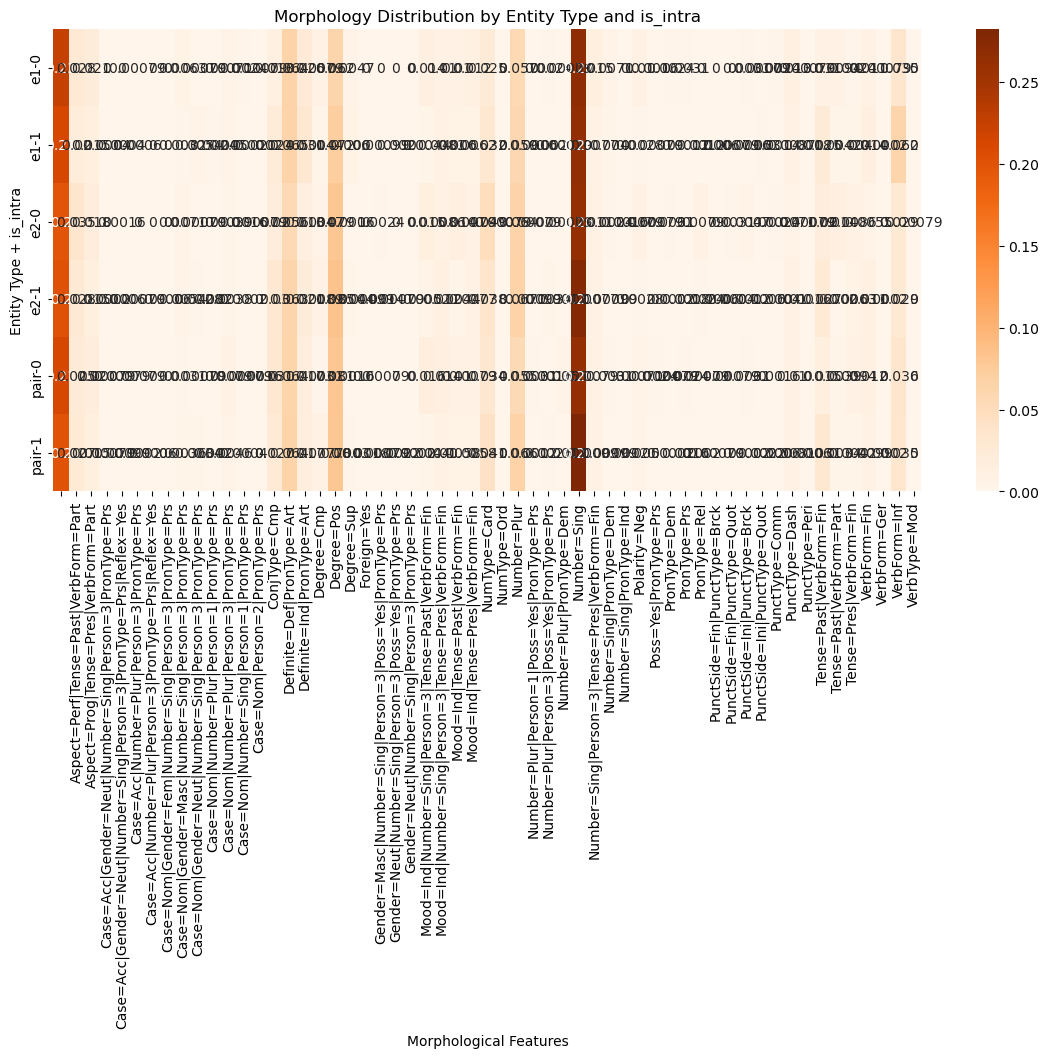

In [26]:
summarize_by_intra(df_analysis)

In [ ]:
# Sử dụng
analyze_correct_prediction_intra(df_analysis)

Số token intra-sentence với prediction đúng: 12648

=== Relation: BEFORE ===
POS distribution:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.075188  0.117951  0.031015  0.044643  0.025376  0.102914   
e2           0.093985  0.124530  0.023026  0.049812  0.034774  0.074248   
pair         0.088346  0.116071  0.029135  0.045113  0.023966  0.089756   

pos              NOUN       NUM      PART      PRON     PROPN     PUNCT  \
entity_type                                                               
e1           0.196429  0.028195  0.030545  0.035244  0.135338  0.033365   
e2           0.209117  0.043703  0.021617  0.030075  0.143797  0.023966   
pair         0.224154  0.030545  0.026786  0.038534  0.135338  0.018797   

pos             SCONJ       SYM      VERB         X  
entity_type                                          
e1           0.018327  0.001410  0.121241  0.

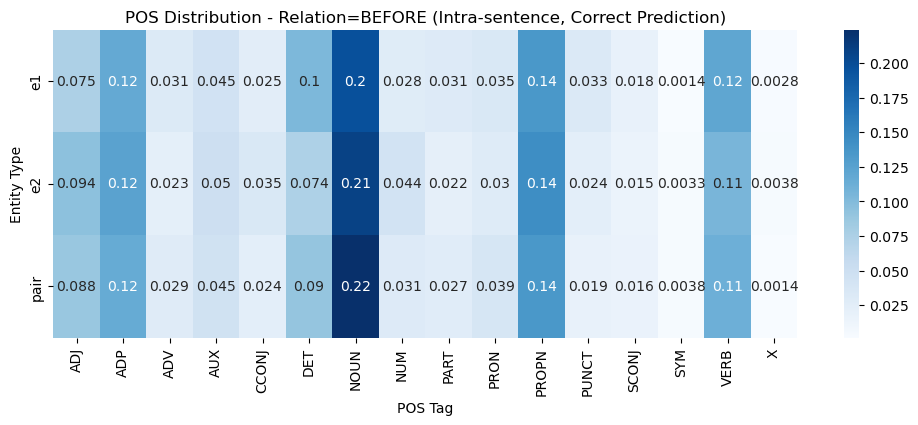

Dependency distribution:
dep              ROOT       acl     acomp     advcl    advmod    agent  \
entity_type                                                              
e1           0.021147  0.009868  0.003759  0.016447  0.034774  0.00047   
e2           0.017387  0.005169  0.005639  0.012218  0.031015  0.00235   
pair         0.013628  0.006579  0.003759  0.018797  0.031955  0.00282   

dep              amod     appos      attr       aux  ...  parataxis     pcomp  \
entity_type                                          ...                        
e1           0.072838  0.014568  0.001410  0.048402  ...    0.00000  0.006579   
e2           0.089756  0.009398  0.003759  0.049812  ...    0.00047  0.005639   
pair         0.083647  0.006579  0.003759  0.045583  ...    0.00047  0.005169   

dep              pobj      poss      prep       prt     punct  quantmod  \
entity_type                                                               
e1           0.093045  0.004699  0.112312  0.004

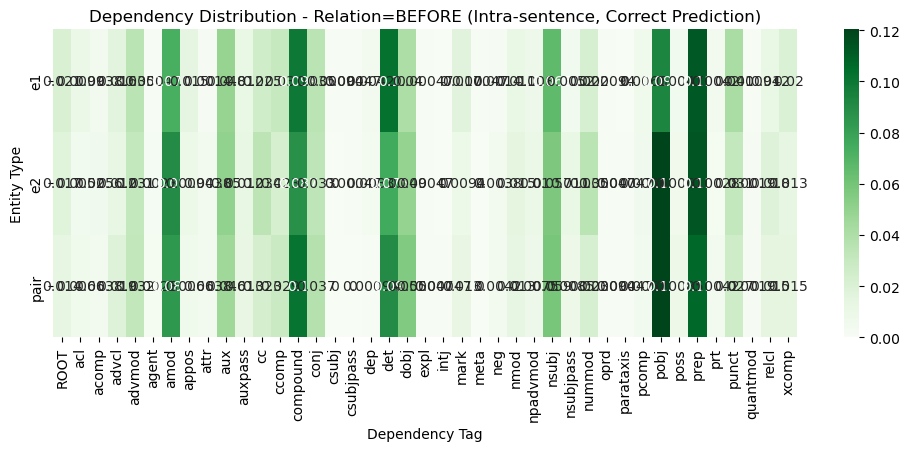

Morphology distribution:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.216165                              0.019737   
e2           0.199248                              0.035244   
pair         0.196429                              0.022086   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.015508   
e2                                       0.012688   
pair                                     0.012688   

morph        Case=Acc|Gender=Neut|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                           
e1                                                     0.00047        
e2                                                     0.00000        
pair                                                   0.00047        

morph        Case=Acc|Gender=Neut|Num

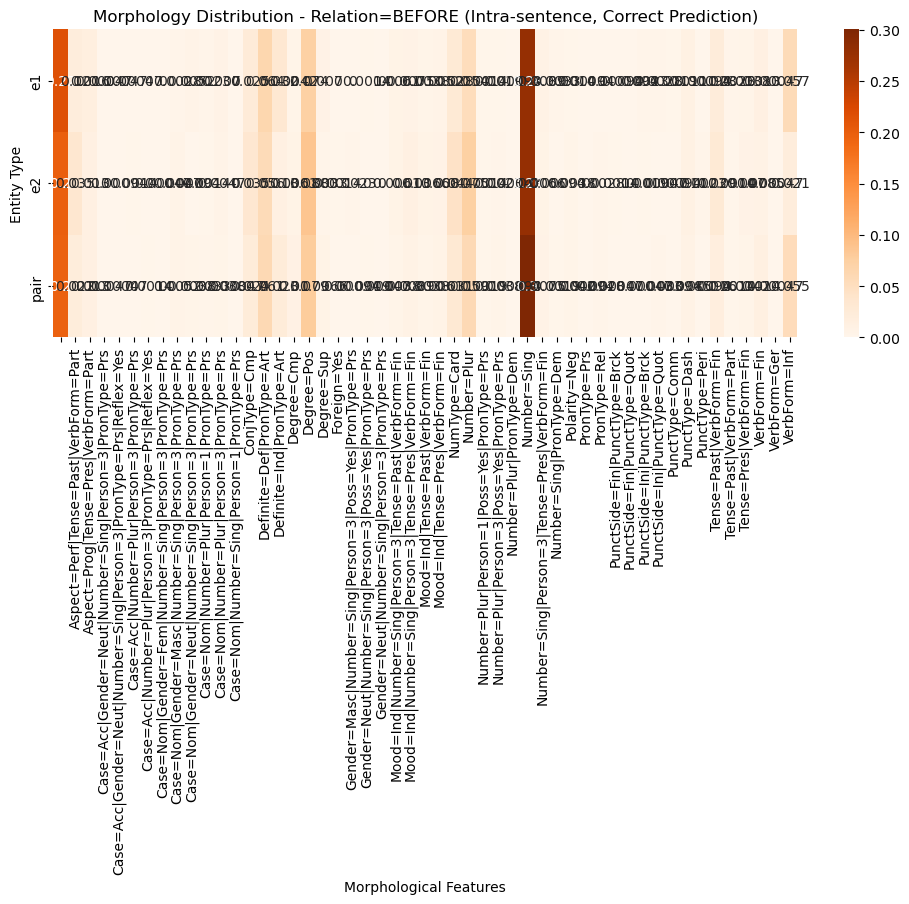


=== Relation: AFTER ===
POS distribution:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.071782  0.120050  0.030322  0.053218  0.024134  0.108911   
e2           0.088490  0.111386  0.040842  0.037129  0.030941  0.109530   
pair         0.080446  0.108292  0.024134  0.047030  0.030941  0.087871   

pos              INTJ      NOUN       NUM      PART      PRON     PROPN  \
entity_type                                                               
e1           0.000000  0.221535  0.038985  0.034035  0.033416  0.102723   
e2           0.000000  0.201733  0.042698  0.029703  0.035891  0.126238   
pair         0.000619  0.192450  0.061262  0.020421  0.036510  0.151609   

pos             PUNCT     SCONJ       SYM      VERB         X  
entity_type                                                    
e1           0.017946  0.011139  0.001238  0.130569  0.000000  
e2           

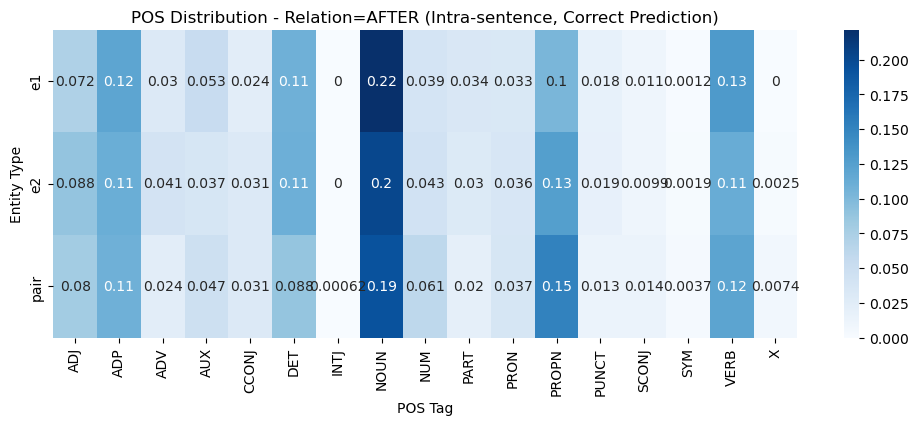

Dependency distribution:
dep              ROOT       acl     acomp     advcl    advmod     agent  \
entity_type                                                               
e1           0.018564  0.008045  0.003094  0.027847  0.034653  0.001238   
e2           0.014851  0.006188  0.002475  0.016089  0.041460  0.001238   
pair         0.032178  0.007426  0.002475  0.018564  0.027847  0.003713   

dep              amod     appos      attr       aux  ...  parataxis     pcomp  \
entity_type                                          ...                        
e1           0.066213  0.006807  0.001856  0.060025  ...   0.000619  0.004332   
e2           0.088490  0.008045  0.001238  0.053837  ...   0.000000  0.004332   
pair         0.092822  0.003713  0.001238  0.040223  ...   0.000000  0.002475   

dep              pobj      poss      prep       prt     punct  quantmod  \
entity_type                                                               
e1           0.108911  0.004950  0.116337  

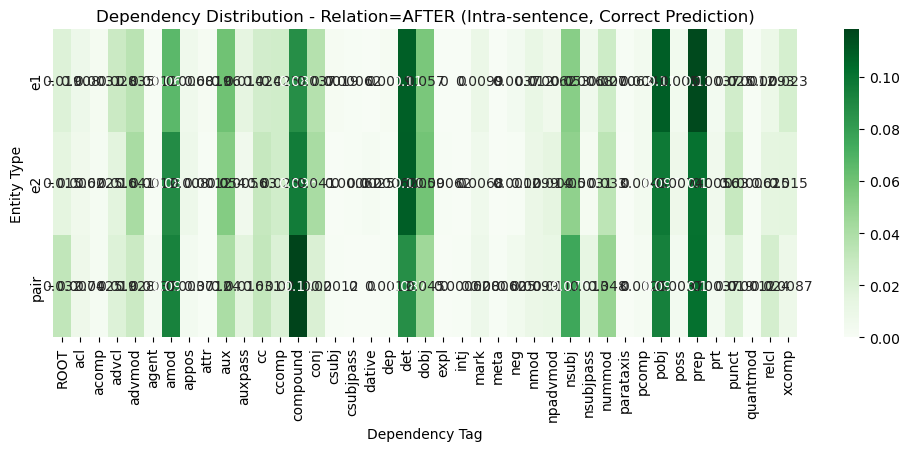

Morphology distribution:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.203589                              0.022277   
e2           0.200495                              0.022896   
pair         0.189356                              0.038366   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.015470   
e2                                       0.014851   
pair                                     0.018564   

morph        Case=Acc|Gender=Neut|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                           
e1                                                    0.000000        
e2                                                    0.000619        
pair                                                  0.001238        

morph        Case=Acc|Number=Plur|Per

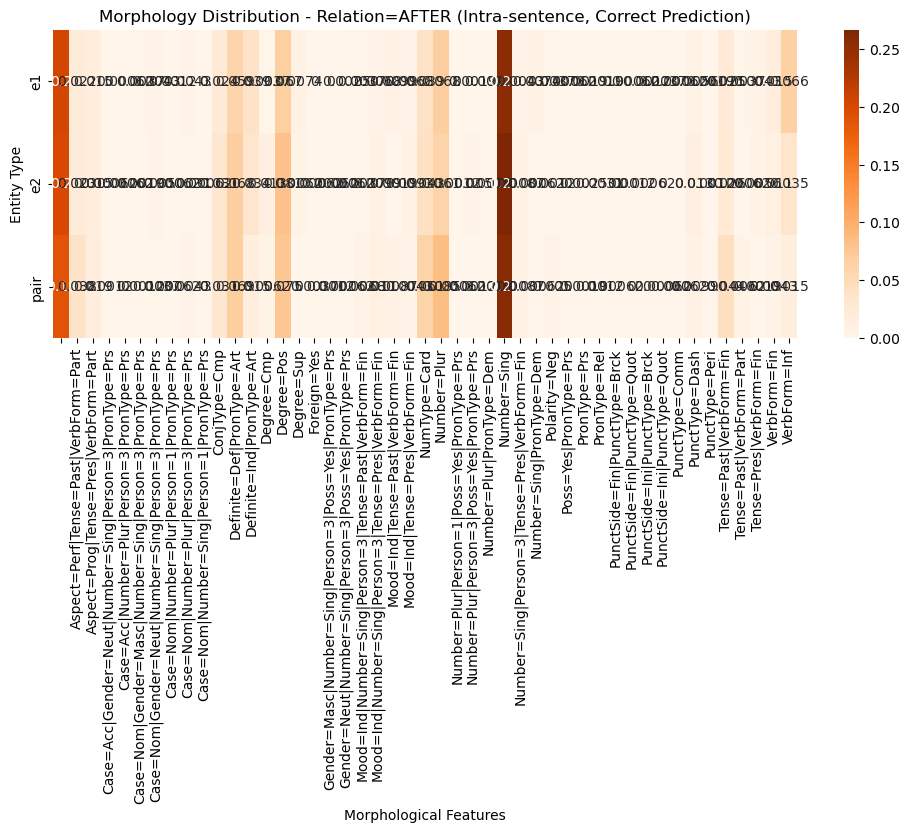


=== Relation: INCLUDES ===
POS distribution:
pos            ADJ   ADP   ADV    AUX  CCONJ    DET   NOUN   NUM   PART  \
entity_type                                                               
e1           0.080  0.10  0.02  0.040   0.03  0.085  0.145  0.03  0.005   
e2           0.065  0.13  0.01  0.065   0.02  0.090  0.190  0.02  0.010   
pair         0.080  0.12  0.02  0.070   0.04  0.060  0.155  0.04  0.005   

pos           PRON  PROPN  PUNCT  SCONJ  VERB     X  
entity_type                                          
e1           0.065   0.16  0.015  0.055  0.16  0.01  
e2           0.065   0.15  0.005  0.050  0.13  0.00  
pair         0.030   0.18  0.000  0.040  0.15  0.01  


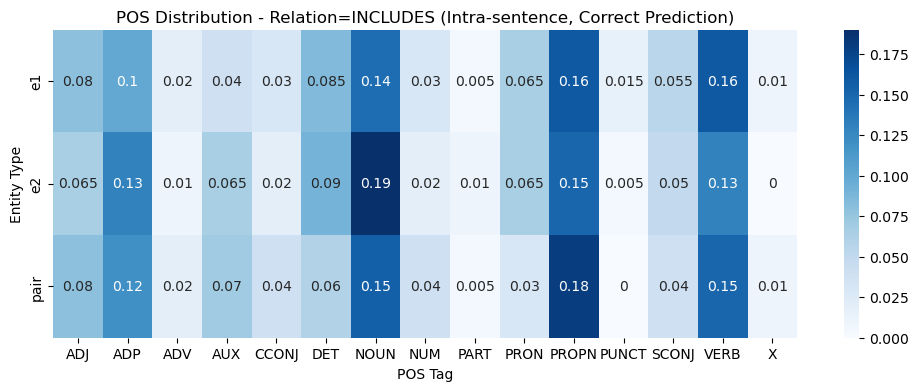

Dependency distribution:
dep           ROOT    acl  acomp  advcl  advmod  agent   amod  appos   attr  \
entity_type                                                                   
e1           0.040  0.000   0.00   0.02   0.050  0.005  0.085  0.010  0.000   
e2           0.005  0.010   0.01   0.01   0.040  0.020  0.060  0.005  0.005   
pair         0.040  0.005   0.00   0.03   0.025  0.000  0.080  0.000  0.000   

dep            aux  ...  nummod  pcomp   pobj   poss   prep    prt  punct  \
entity_type         ...                                                     
e1           0.035  ...   0.015  0.015  0.115  0.005  0.105  0.000  0.020   
e2           0.040  ...   0.015  0.020  0.135  0.010  0.090  0.015  0.015   
pair         0.060  ...   0.025  0.005  0.100  0.010  0.135  0.000  0.010   

dep          quantmod  relcl  xcomp  
entity_type                          
e1              0.005  0.020  0.005  
e2              0.000  0.000  0.020  
pair            0.015  0.005  0.005  

[3

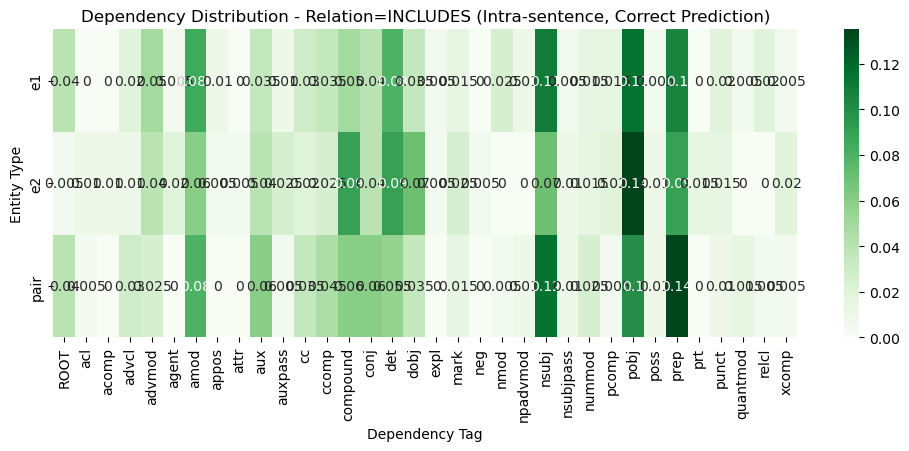

Morphology distribution:
morph              Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                               
e1           0.23                                  0.02   
e2           0.22                                  0.03   
pair         0.20                                  0.02   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                          0.020   
e2                                          0.040   
pair                                        0.015   

morph        Case=Acc|Number=Plur|Person=3|PronType=Prs  \
entity_type                                               
e1                                                0.005   
e2                                                0.000   
pair                                              0.000   

morph        Case=Nom|Gender=Masc|Number=Sing|Person=3|PronType=Prs  \
entity_type                                   

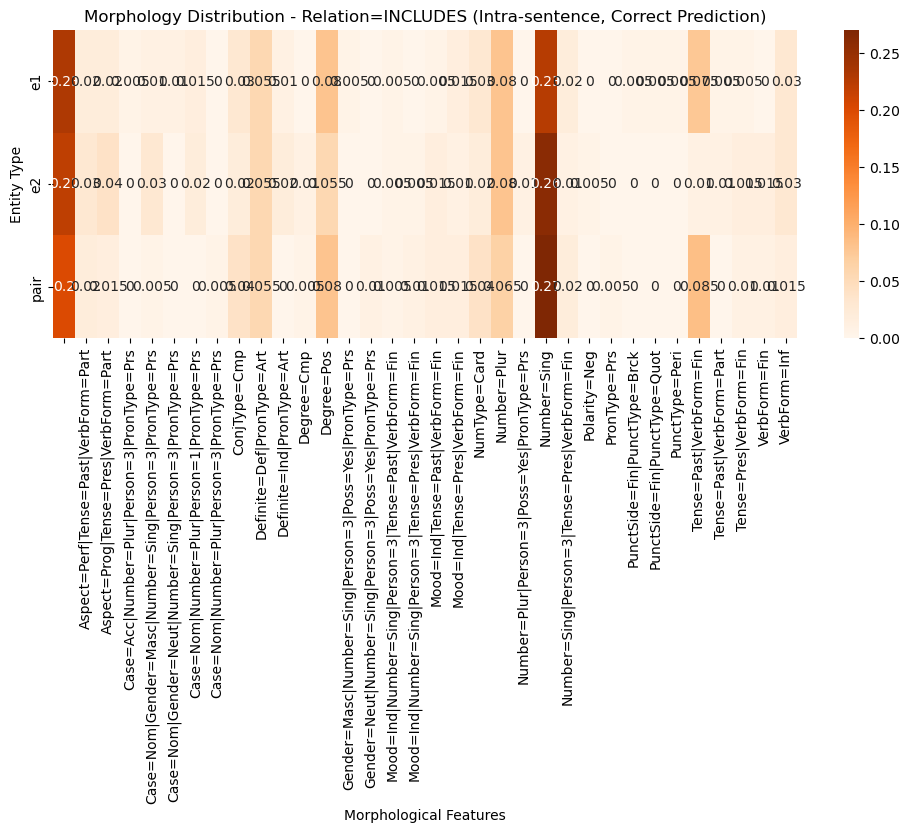


=== Relation: SIMULTANEOUS ===
POS distribution:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.035714  0.125000  0.017857  0.053571  0.017857  0.035714   
e2           0.107143  0.089286  0.053571  0.071429  0.017857  0.053571   
pair         0.089286  0.160714  0.035714  0.089286  0.053571  0.035714   

pos              NOUN       NUM      PART      PRON     PROPN     PUNCT  \
entity_type                                                               
e1           0.303571  0.035714  0.000000  0.071429  0.125000  0.035714   
e2           0.178571  0.017857  0.017857  0.053571  0.214286  0.017857   
pair         0.142857  0.035714  0.000000  0.035714  0.178571  0.000000   

pos             SCONJ      VERB         X  
entity_type                                
e1           0.035714  0.089286  0.017857  
e2           0.053571  0.053571  0.000000  
pair         0.035714 

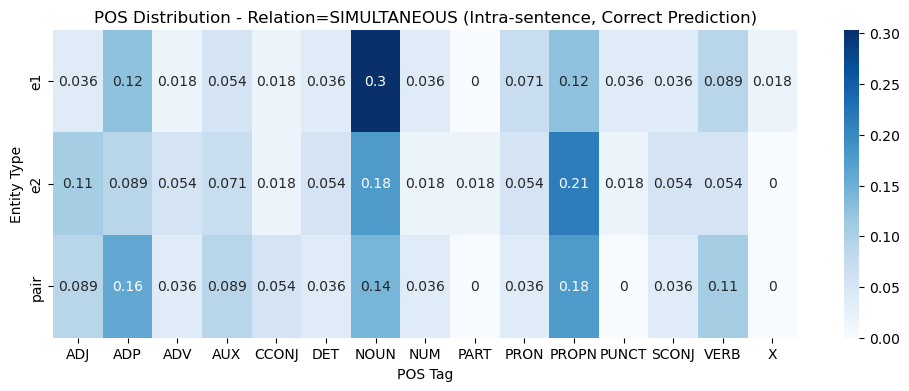

Dependency distribution:
dep              ROOT     advcl    advmod     agent      amod     appos  \
entity_type                                                               
e1           0.035714  0.000000  0.053571  0.000000  0.035714  0.017857   
e2           0.000000  0.017857  0.053571  0.017857  0.125000  0.000000   
pair         0.053571  0.000000  0.035714  0.000000  0.071429  0.017857   

dep               aux   auxpass        cc     ccomp  ...      nmod  npadvmod  \
entity_type                                          ...                       
e1           0.017857  0.017857  0.017857  0.017857  ...  0.035714  0.017857   
e2           0.035714  0.035714  0.017857  0.035714  ...  0.000000  0.000000   
pair         0.053571  0.035714  0.053571  0.000000  ...  0.053571  0.000000   

dep             nsubj  nsubjpass    nummod      pobj      prep     punct  \
entity_type                                                                
e1           0.142857   0.017857  0.000000  0.

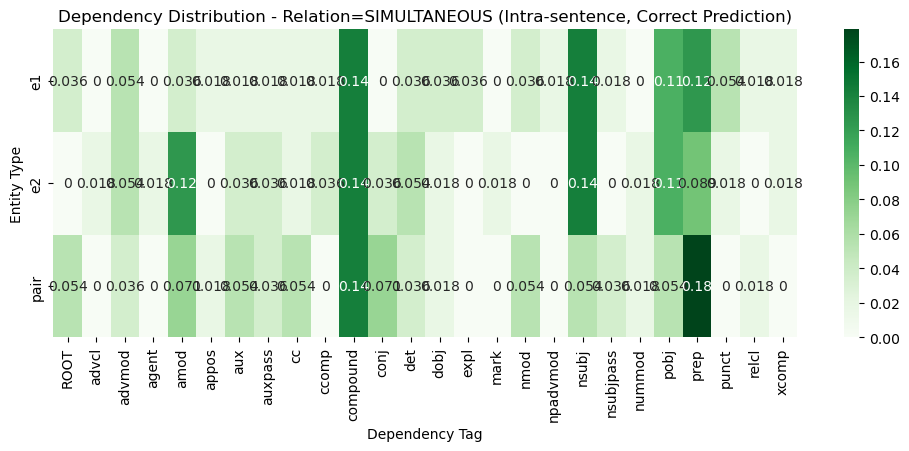

Morphology distribution:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.250000                              0.017857   
e2           0.196429                              0.000000   
pair         0.232143                              0.017857   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.000000   
e2                                       0.017857   
pair                                     0.000000   

morph        Case=Nom|Gender=Neut|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                           
e1                                                    0.017857        
e2                                                    0.035714        
pair                                                  0.017857        

morph        Case=Nom|Number=Plur|Per

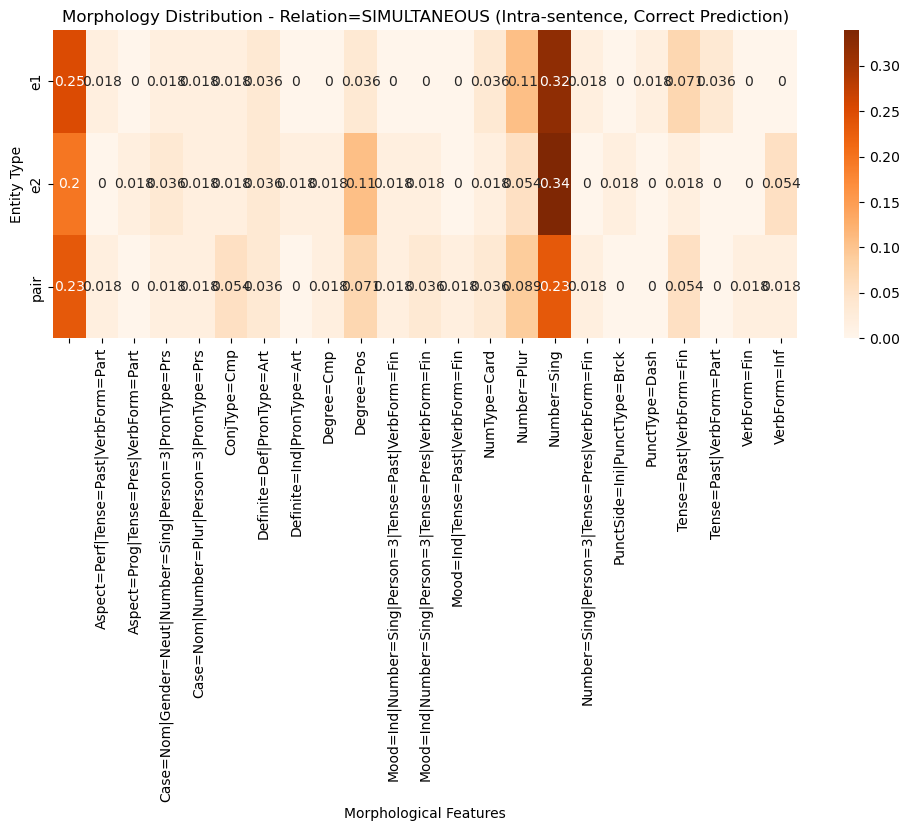


=== Relation: IS_INCLUDED ===
POS distribution:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.092593  0.083333  0.032407  0.106481  0.013889  0.097222   
e2           0.097222  0.125000  0.027778  0.046296  0.032407  0.087963   
pair         0.087963  0.138889  0.013889  0.037037  0.009259  0.097222   

pos              NOUN       NUM      PART      PRON     PROPN     PUNCT  \
entity_type                                                               
e1           0.217593  0.013889  0.032407  0.046296  0.083333  0.023148   
e2           0.162037  0.027778  0.027778  0.027778  0.148148  0.009259   
pair         0.208333  0.013889  0.041667  0.023148  0.157407  0.009259   

pos             SCONJ      VERB         X  
entity_type                                
e1           0.027778  0.125000  0.004630  
e2           0.037037  0.134259  0.009259  
pair         0.027778  

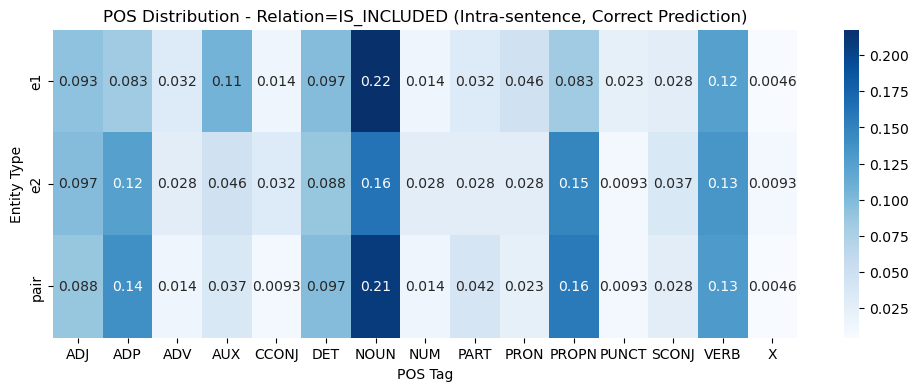

Dependency distribution:
dep              ROOT       acl     acomp     advcl    advmod    agent  \
entity_type                                                              
e1           0.013889  0.004630  0.004630  0.009259  0.041667  0.00463   
e2           0.032407  0.004630  0.009259  0.046296  0.046296  0.00463   
pair         0.027778  0.018519  0.013889  0.018519  0.013889  0.00000   

dep              amod     appos     attr       aux  ...  parataxis     pcomp  \
entity_type                                         ...                        
e1           0.087963  0.009259  0.00463  0.101852  ...    0.00463  0.013889   
e2           0.097222  0.004630  0.00000  0.055556  ...    0.00000  0.004630   
pair         0.092593  0.000000  0.00463  0.046296  ...    0.00000  0.000000   

dep              pobj      poss      prep      prt     punct  quantmod  \
entity_type                                                              
e1           0.078704  0.009259  0.074074  0.00463  0.0

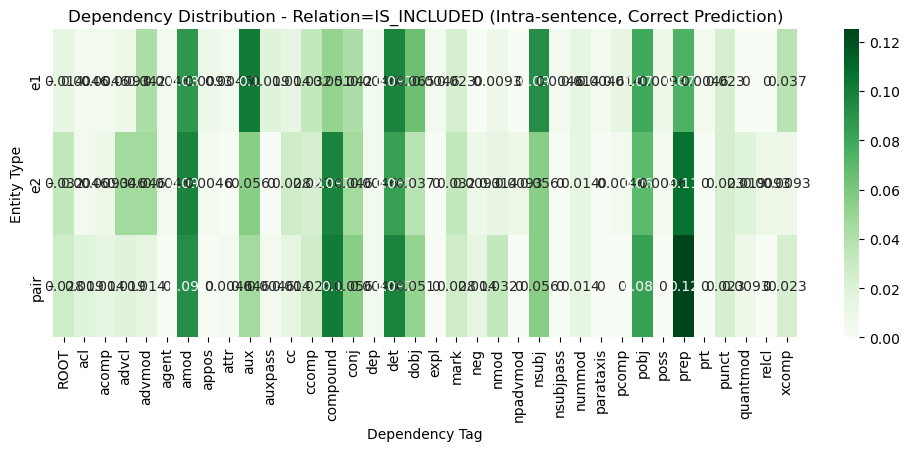

Morphology distribution:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.185185                              0.013889   
e2           0.231481                              0.023148   
pair         0.208333                              0.041667   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.018519   
e2                                       0.018519   
pair                                     0.013889   

morph        Case=Acc|Gender=Neut|Number=Sing|Person=3|PronType=Prs|Reflex=Yes  \
entity_type                                                                      
e1                                                     0.00000                   
e2                                                     0.00463                   
pair                                                   0.00000   

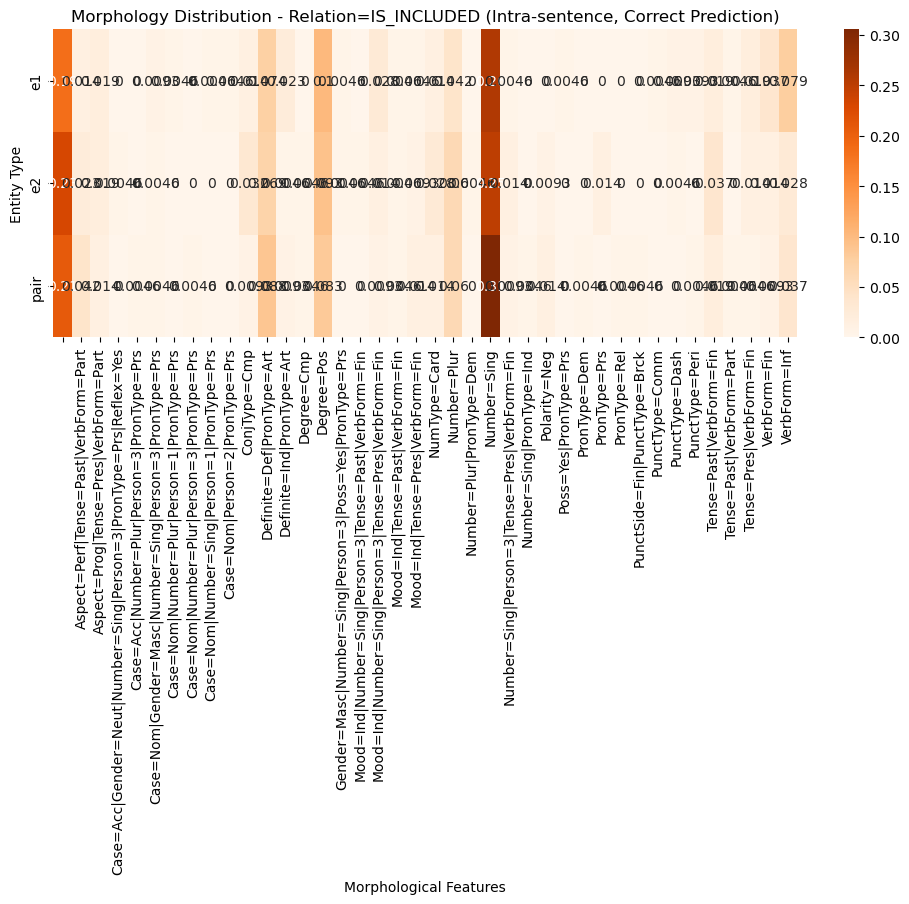

In [27]:
analyze_pos_dep_morph_by_relation(df_analysis)